In [ ]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("ccmusic-database/music_genre")

In [4]:
train_df = ds["train"].to_pandas()

In [9]:
ds["train"][0]


{'mel': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=496x369>,
 'cqt': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=496x369>,
 'chroma': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=496x369>,
 'fst_level_label': 1,
 'sec_level_label': 4,
 'thr_level_label': 6}

In [14]:
ds["train"]


Dataset({
    features: ['mel', 'cqt', 'chroma', 'fst_level_label', 'sec_level_label', 'thr_level_label'],
    num_rows: 29100
})

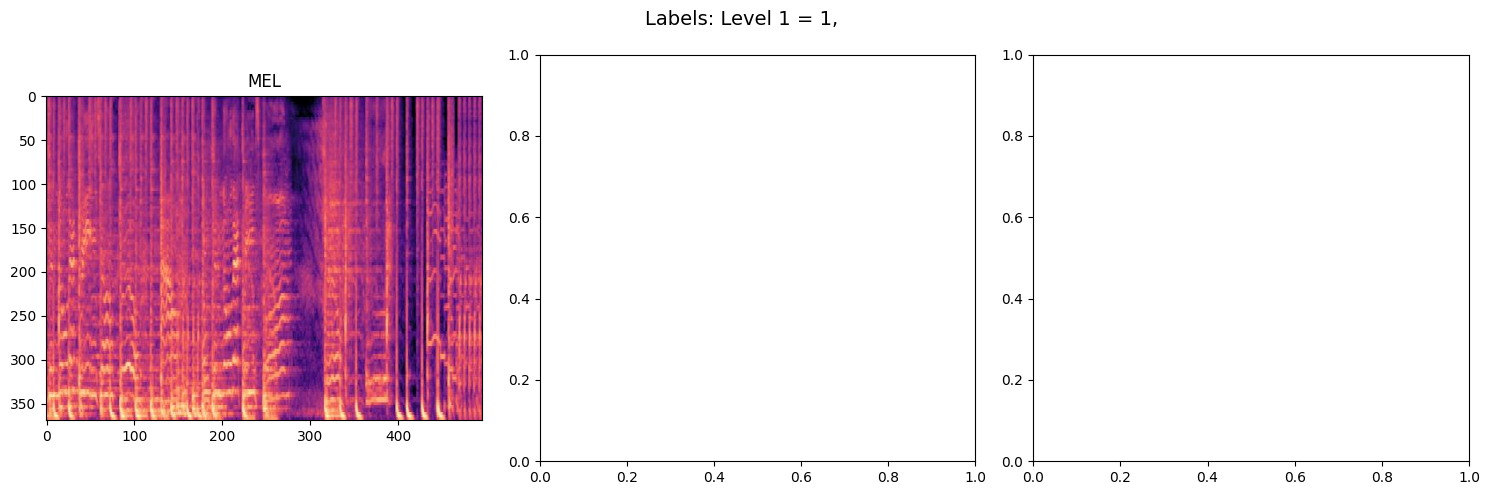

In [13]:
import matplotlib.pyplot as plt
example = ds["train"][4]
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, (key, image) in zip(axs, [(k, example[k]) for k in ['mel']]):
    ax.imshow(image)
    ax.set_title(key.upper())
    #ax.axis('off')

# show labels in the plot title or below
fig.suptitle(f"Labels: Level 1 = {example['fst_level_label']}, "
             #f"Level 2 = {example['sec_level_label']}, "
             #f"Level 3 = {example['thr_level_label']}", 
             ,fontsize=14)

plt.tight_layout()
plt.show()

In [25]:
from pathlib import Path
import os
num_songs = 0
root = r"P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\training\metal"
for path, subdirs, files in os.walk(root):
    for name in files:
        #print(os.path.join(path, name))
        num_songs += 1
print(num_songs)

29


In [75]:
from pathlib import Path
import os
from os import listdir
from os.path import isfile, join
num_songs = 0
songs_names = set([])
root = r"P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\training\classical"
for path, subdirs, files in os.walk(root):
   for name in files:
      songs_names.add(name)

In [76]:
songs_names

{'1-concerto_no.1_in_d_major_rv_2.mp3',
 '1-handel_trio_sonata_op._5_no.4.mp3',
 '1-ma_belle_si_ton_ame_(gilles_durant_de_la_bergerie).mp3',
 '1-matteis_ground_after_the_scotch_humour.mp3',
 '1-oxenford_(anon).mp3',
 '1-pandolfi_la_berbabea_op_4_#1.mp3',
 '1-prelude_(phalese).mp3',
 '1-preludio_i.mp3',
 '1-recercar_1.mp3',
 '1-set_a_6_in_c_major.mp3',
 '1-suite_iii_in_do_maggiore_-_prelude.mp3',
 '1-to_thee_we_sing_bulgarian_chant_tone_legetos.mp3',
 '1-we_are_guarded_by_the_cross.mp3',
 '1-widmung.mp3',
 '10-gigue.mp3',
 '10-guillarde_milanoise_(morlaye).mp3',
 '10-i_care_not_for_these_ladies_(thomas_campian).mp3',
 '10-johann_christian_bach_(arr_mozart)_concerto_in_d_k107_(1772).mp3',
 '10-partita_prima_in_mi_minore_-_double.mp3',
 '10-recercar_10_(steel_string_guitar).mp3',
 '10-sonata_iii_moderato.mp3',
 '10-tamerlano_act_ii_track_10.mp3',
 '10-waissel_polish_dance.mp3',
 '11-cesar_franck_sonata_for_violi.mp3',
 '11-christe.mp3',
 '11-fantasia.mp3',
 '11-fantasia_11.mp3',
 '11-gall

In [27]:
def get_num_songs(root):
    num_songs = 0
    for path, subdirs, files in os.walk(root):
        for name in files:
            #print(os.path.join(path, name))
            num_songs += 1
    print(num_songs)
    return num_songs


In [ ]:
metal_train = get_num_songs(r"P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\training\metal")
metal_eval = get_num_songs(r"P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\evaluation\metal")

# 1517 artists dataset

In [1]:
import os
num_songs = 0
root = r"P:\datasets\geenres\1517\1517\1517_Artists"
for path, subdirs, files in os.walk(root):
    if len(subdirs) != 0:
        print(subdirs)
    for name in files:
        #print(os.path.join(path, name))
        num_songs += 1
print(num_songs)

['Alternative_and_Punk', 'Blues', 'Childrenss', 'Classical', 'Comedy_and_Spoken_Word', 'Country', 'Easy_Listening_and_Vocals', 'Electronic_and_Dance', 'Folk', 'Hip-Hop', 'Jazz', 'Latin', 'New_Age', 'Reggae', 'Religious', 'Rock_and_Pop', 'R_and_B_and_Soul', 'Soundtracks_and_More', 'World']
3181


## cutting and downsampling

In [11]:
import torchaudio
import numpy as np
from pydub import AudioSegment
import torch
import librosa
import soundfile as sf
from beat_this.preprocessing import LogMelSpect, load_audio
from pathlib import Path
def get_target_name(orig_path, target_folder):
    name = Path(orig_path).stem
    file_path =  os.path.join(target_folder, f"{name}.wav")
    return file_path

def preprocess_audio(path, target_sr = 22050, target_len = 30, cut = True):
    try:
        waveform, sr =load_audio(path)
    except Exception:
        try:
            audio = AudioSegment.from_mp3(path)
            samples = np.array(audio.get_array_of_samples()).astype(np.float32) / (2 ** 15)
            sr = audio.frame_rate
            waveform = torch.tensor(samples).reshape(-1, audio.channels)
            waveform = waveform.numpy()
        except Exception:
             raise RuntimeError(f'Could not load audio from "{path}".')
    
    if cut:
        num_samples = waveform.shape[0]
        segment_samples = int(target_len*sr)
        center = num_samples //2
        start = max(center - segment_samples //2, 0)
        end = start + segment_samples
        waveform = waveform[start:end, :]
    #print(start/(sr*60))
    waveform = waveform.mean(axis=1)  # shape: (samples,)

    # Convert to torch tensor with correct shape: (1, num_samples)
    waveform_reduced = librosa.resample(waveform, orig_sr=sr,target_sr=target_sr)
    return waveform_reduced

In [13]:
target_sr = 22050
path = r"P:\datasets\geenres\1517\1517_new\1517\1517-Artists\Alternative_and_Punk\\3rd_Lane-Nightmare_of_Reality.mp3"
waveform_reduced = preprocess_audio(path)
sf.write("Blue_Attitude-Stormy_Weather_22.wav", waveform_reduced,target_sr)

2.201374149659864


In [14]:
import IPython.display as ipd
ipd.Audio(waveform_reduced, rate=22050)

In [29]:
from pathlib import Path
path = r"1517-Artists/Blues/Blue_Attitude-Stormy_Weather.mp3"
name = Path(path).stem
name

'Blue_Attitude-Stormy_Weather'

In [3]:
def get_target_name(orig_path, target_folder):
    name = Path(orig_path).stem
    file_path =  os.path.join(target_folder, f"{name}.wav")
    return file_path

In [5]:
import os 
target_folder = r"C:\Users\Marina\genres\1517-Artists_reduced"
folder = r"C:\Users\Marina\genres\1517-Artists\Blues"
genre = os.path.basename(folder)
target_folder = os.path.join(target_folder, genre)
target_sr = 22050

path = r"1517-Artists/Blues/Blue_Attitude-Stormy_Weather.mp3"
save_path = get_target_name(path, target_folder)
waveform_reduced = preprocess_audio(path)

sf.write(save_path, waveform_reduced,target_sr)

In [14]:
import librosa
import soundfile as sf
import soxr
reduced_sr = 22050
#waveform_reduced = soxr.resample(waveform, in_rate = sr, out_rate = 22050)
waveform_reduced = librosa.resample(waveform, orig_sr=sr,target_sr=reduced_sr)
sf.write("Alan_Fox_and_The_Shooters_Band-Lost_Without_Your_Love_22.wav", waveform_reduced,reduced_sr)

In [ ]:
import librosa
import soundfile as sf      # sanity check that the obtained files have proper resolution
import soxr
y, sr = librosa.load("1517-Artists_reduced/Blues/Blue_Attitude-Stormy_Weather.wav")

In [ ]:
y, sr = librosa.load("gtzan_old/gtzan_old/blues/blues.00000.wav") # gtzan has already sr 22050
sr

22050

In [13]:
import IPython.display as ipd
ipd.Audio(waveform_reduced, rate=22050)

In [ ]:
root = r"C:\Users\Marina\genres\1517-Artists"
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
subfolders

In [ ]:
import os 
from os import listdir
from os.path import isfile, join
from tqdm import tqdm

root = r"P:\datasets\geenres\1517\1517_new\1517\1517-Artists" #r"C:\Users\Marina\genres\1517-Artists_reduced"
new_root = r"P:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced"  #r"C:\Users\Marina\genres\1517-Artists"
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
#folder = 'C:\\Users\\Marina\\genres\\1517-Artists\\Blues'
for folder in subfolders:
    genre = os.path.basename(folder)
    if genre not in ['Childrenss','Religious', 'Comedy_and_Spoken_Word' ]:
        print(f" preprocessing {genre}")
        target_folder = os.path.join(new_root, genre)
        target_sr = 22050
        onlyfiles = [f for f in listdir(folder) if isfile(join(folder, f))]
        os.makedirs(target_folder, exist_ok = True)
        for file in tqdm(onlyfiles):
            path = os.path.join(folder, file)
            save_path = get_target_name(path, target_folder)
            #print(save_path)
            try:
                waveform_reduced = preprocess_audio(path)
                sf.write(save_path, waveform_reduced,target_sr)
            except Exception as e:
                print(f" skipping file {file} because it caused some problems")
                print(e)
           


In [40]:
audio_path = r"C:\Users\Marina\genres\1517-Artists_reduced\Blues\Ageing_hippie_groove_syndicate-Blues_for_Ben.wav"
waveform, sr = load_audio(audio_path)

In [42]:
sr

22050

In [97]:
def clean_genres(keys, dictionary):
    for key in keys:
        if key in dictionary:
            del dictionary[key]
    return dictionary

## visualizations

In [31]:
from os import listdir
from os.path import isfile, join
#new_root  = r"C:\Users\Marina\genres\1517-Artists_reduced"
root = r"P:\datasets\geenres\1517\1517_new\1517\1517-Artists" # r"C:\Users\Marina\genres\1517-Artists"
genre_distributions = {}
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
for folder in subfolders:
    onlyfiles = [f for f in listdir(folder) if isfile(join(folder, f))]
    genre_distributions[folder.split("\\")[-1]] = len(onlyfiles)
#genre_distributions = clean_genres(['Childrenss','Religious', 'Comedy_and_Spoken_Word' ], genre_distributions)

In [ ]:
from os import listdir    # finding the average duration of every genre in the dataset
from os.path import isfile, join
import librosa
import numpy
from tqdm import tqdm
genre_distribution_durations = {}
genres_to_omit = ['Childrenss','Religious', 'Comedy_and_Spoken_Word' ]
subfolders = [ f.path for f in os.scandir(new_root) if f.is_dir() ]
for folder in tqdm(subfolders):
    if folder not in genres_to_omit:
        onlyfiles = [f for f in listdir(folder) if isfile(join(folder, f))]
        durations = [librosa.get_duration(filename=join(folder, file)) for file in onlyfiles]
        genre_distribution_durations[folder.split("\\")[-1]] = numpy.average(durations)
genre_distribution_durations = clean_genres(genres_to_omit, genre_distribution_durations)

In [34]:
import math
import numpy as np
genre_distribution_durations_sec = {key: float(np.round(value / 60, 3)) for key, value in genre_distribution_durations.items()}
genre_distribution_durations_sec["R&B_and_Soul"] = genre_distribution_durations_sec.pop("R_and_B_and_Soul")
genres_sec_sorted = {k: v for k, v in sorted(genre_distribution_durations_sec.items(), key=lambda item: item[1])}
genres_sec_sorted 

{'Soundtracks_and_More': 3.283,
 'Folk': 3.43,
 'Country': 3.443,
 'Latin': 3.68,
 'Hip-Hop': 3.763,
 'Easy_Listening_and_Vocals': 3.814,
 'Alternative_and_Punk': 3.834,
 'World': 3.906,
 'Reggae': 3.993,
 'Rock_and_Pop': 3.999,
 'Blues': 4.019,
 'Classical': 4.045,
 'R&B_and_Soul': 4.152,
 'New_Age': 4.407,
 'Jazz': 4.793,
 'Electronic_and_Dance': 5.081}

C:\Users\polin\AppData\Local\Temp\ipykernel_20744\1067348595.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_genres)


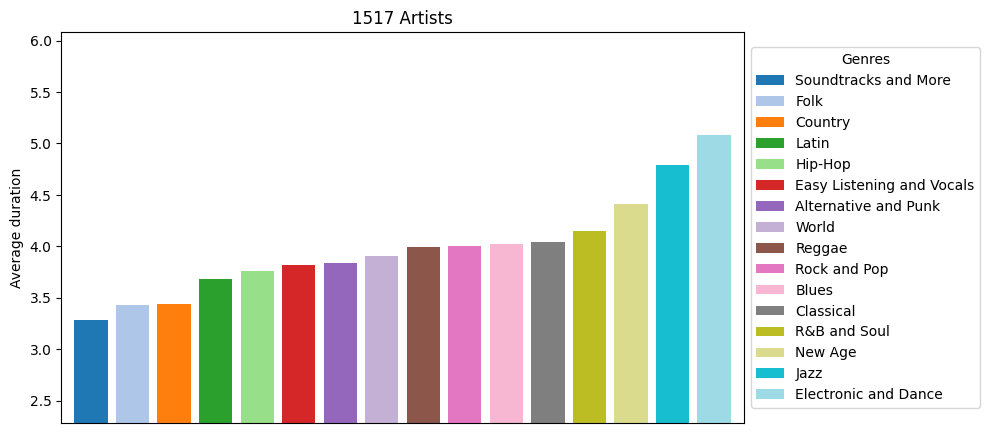

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.patches import Patch

# Example: replace with your actual data
# genres_sorted = {"Country": 185, "Folk": 182, ...}
names = [name.replace("_", " ") for name in genres_sec_sorted .keys()]
values = list(genres_sec_sorted .values())
num_genres = len(names)

# Generate colors
cmap = cm.get_cmap('tab20', num_genres)
colors = [cmap(i) for i in range(num_genres)]

# Plot
plt.figure(figsize=(10, 4.5))
x_pos = np.arange(num_genres)
bars = plt.bar(x_pos, values, color=colors)

# Hide x-axis labels
plt.xticks([])  # removes genre names below bars

# Set limits and labels
plt.ylim(min(values) - 1, max(values) + 1)
plt.ylabel("Average duration")
plt.title("1517 Artists")
plt.margins(x=0.02)

# Add legend on the side
legend_elements = [Patch(facecolor=colors[i], label=names[i]) for i in range(num_genres)]
plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="Genres")

plt.tight_layout()
#plt.savefig("1517_artists_sec_average.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [32]:
genre_distributions["R&B_and_Soul"] = genre_distributions["R_and_B_and_Soul"]
genres_sorted = {k: v for k, v in sorted(genre_distributions.items(), key=lambda item: item[1])}
genres_sorted

{'Classical': 125,
 'Comedy_and_Spoken_Word': 134,
 'Soundtracks_and_More': 150,
 'Hip-Hop': 155,
 'World': 158,
 'Latin': 163,
 'Childrenss': 164,
 'Electronic_and_Dance': 164,
 'Reggae': 172,
 'Religious': 172,
 'Easy_Listening_and_Vocals': 175,
 'New_Age': 175,
 'R_and_B_and_Soul': 175,
 'R&B_and_Soul': 175,
 'Jazz': 177,
 'Alternative_and_Punk': 182,
 'Rock_and_Pop': 182,
 'Folk': 185,
 'Blues': 186,
 'Country': 187}

In [ ]:
genres_sorted["R&B_and_Soul"] = genres_sorted.pop("R_and_B_and_Soul")

C:\Users\polin\AppData\Local\Temp\ipykernel_3408\2146192579.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_genres)


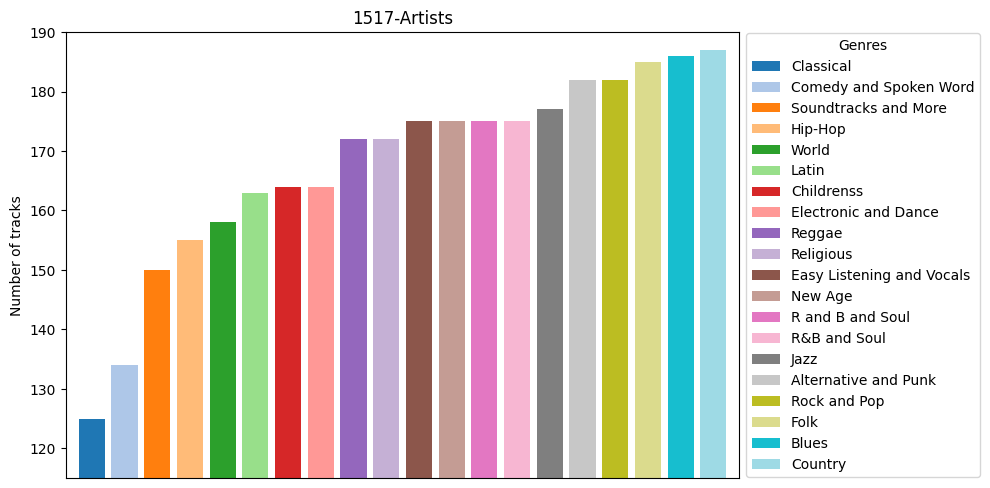

In [35]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.patches import Patch

# Example: replace with your actual data
# genres_sorted = {"Country": 185, "Folk": 182, ...}
names = [name.replace("_", " ") for name in genres_sorted.keys()]
values = list(genres_sorted.values())
num_genres = len(names)

# Generate colors
cmap = cm.get_cmap('tab20', num_genres)
colors = [cmap(i) for i in range(num_genres)]

# Plot
plt.figure(figsize=(10, 5.2))
x_pos = np.arange(num_genres)
bars = plt.bar(x_pos, values, color=colors)

# Hide x-axis labels
plt.xticks([])  # removes genre names below bars

# Set limits and labels
plt.ylim(min(values) - 10, max(values) + 3)
plt.ylabel("Number of tracks")
plt.title("1517-Artists")
plt.margins(x=0.02)

# Add legend on the side
legend_elements = [Patch(facecolor=colors[i], label=names[i]) for i in range(num_genres)]
plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="Genres")

plt.tight_layout()
plt.savefig("1517_artists_vertical.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [6]:
songs_names = set([])
root = r"P:\datasets\geenres\1517\1517\1517_Artists\Classical"
for path, subdirs, files in os.walk(root):
   for name in files:
      songs_names.add(name)

## attempting to split so that tracks from the same artist are in the same split 

getting corresponding artist for each track 

In [ ]:
import os    # old, for the original 1517 dataset
from mutagen.easyid3 import EasyID3 
artists = {} 
for filename in os.listdir(root):
    if filename.lower().endswith(".mp3"):
        file_path = os.path.join(root, filename)
        try:
            audio = EasyID3(file_path)
            artist = audio.get('artist', ['Unknown'])[0]
            artists.setdefault(artist, []).append(filename)
            #print(f"{filename} → {artist}")
        except Exception as e:
            print(f"Error reading {filename}: {e}")

In [ ]:
def get_artist(filename):
    
    file_path = os.path.join(root, filename)
    if "___" in filename:
        artist = filename.split("___")[0]
    elif "-" in filename:
        artist = filename.split("-")[0]
    else:
        #print(f"problems with {file_path}")
        raise Exception(f"problems with {file_path}")
        #artists.setdefault(artist, []).append(file_path)
    return artist

In [51]:
import os 
root = r"P:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced\Classical"
artists = {}
for filename in os.listdir(root):
    #print(filename)
    if filename.lower().endswith("wav"):
        file_path = os.path.join(root, filename)
        artist = get_artist(filename)
        artists.setdefault(artist, []).append(file_path)
        #print(artist)

In [52]:
artists

{'A.A.Owen': ['P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Classical\\A.A.Owen-Mysteries_1.wav',
  'P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Classical\\A.A.Owen-The_Dancer.wav'],
 'Aleksandr_Tsiboulski': ['P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Classical\\Aleksandr_Tsiboulski-Enrique_Granados-Spanish_dance_No.5.wav',
  'P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Classical\\Aleksandr_Tsiboulski-Issaac_Albeniz-Zambra_Granadina.wav'],
 'Amael_Piano_Trio': ['P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Classical\\Amael_Piano_Trio-J._Brahms-Allegro_moltoTrio_C_minor.wav'],
 'american_baroque': ['P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Classical\\american_baroque___4-musette_suite_from_les_fetes.wav',
  'P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Classical\\american_baroque___9-concerto_no.3_in_f_major_rv_2.wav'],
 'andr

In [23]:
artists_len = {key: len(artists[key]) for key, value in artists.items()}  # getting counts for each artist


In [ ]:
import pandas as pd     # creating a df with all information about the 1517 tracks (old)
header = ["title",  "genre", "artist", "filepath"]
dataset_table =dict((el,[]) for el in header)
root = r"P:\datasets\geenres\1517\1517\1517_Artists"
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
for folder in subfolders:
    genre = folder.split("\\")[-1]
    for f in listdir(folder) :
        file = join(folder, f)
        if isfile(file):
            dataset_table["title"].append(f)
            dataset_table["filepath"].append(file)
            dataset_table["genre"].append(genre)
            audio = EasyID3(file)
            artist = audio.get('artist', ['Unknown'])[0]
            dataset_table["artist"].append(artist)


In [59]:
import pandas as pd
root = r"P:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced"
header = ["title",  "genre", "artist", "filepath"]
dataset_table =dict((el,[]) for el in header)
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]   # new
for folder in subfolders:
    genre = folder.split("\\")[-1]
    for f in listdir(folder) :
        file = join(folder, f)
        if isfile(file):
            dataset_table["title"].append(f)
            dataset_table["filepath"].append(file)
            dataset_table["genre"].append(genre)
            # audio = EasyID3(file)
            # artist = audio.get('artist', ['Unknown'])[0]
            artist = get_artist(f)
            dataset_table["artist"].append(artist)


In [69]:
dataset_df = pd.DataFrame.from_dict(dataset_table)
#dataset_df.loc[dataset_df["genre"] == "Classical"]
dataset_df.head(10)
dataset_df.to_csv("merged_dataset.csv")

In [80]:
os.path.isfile("merged_dataset1.csv")

False

making a split so that the it it homogeneous by genre and the tracks of the same artists end up in the same split


In [85]:
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
df = pd.read_csv("merged_dataset.csv")
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# First split into train+val vs test (e.g. 80/20)
for trainval_idx, test_idx in sgkf.split(df, df['genre'], groups=df['artist']):   # sgkf makes sure that one artist can't end up in
    df_trainval = df.iloc[trainval_idx]                                           # multiple splits
    df_test = df.iloc[test_idx]
    break
for train_idx, val_idx in sgkf.split(df_trainval, df_trainval['genre'], groups=df_trainval['artist']):
    df_train = df_trainval.iloc[train_idx]
    df_val = df_trainval.iloc[val_idx]
    break
df_test.head()


,Unnamed: 0,title,genre,artist,filepath
2,2,Alexisonfire-Accidents.wav,Alternative_and_Punk,Alexisonfire,P:\datasets\geenres\1517\1517_new\1517\1517-Ar...
3,3,Alexisonfire-A_Dagger_Through_The_Heart_of_St....,Alternative_and_Punk,Alexisonfire,P:\datasets\geenres\1517\1517_new\1517\1517-Ar...
13,13,Azure_Ray-November.wav,Alternative_and_Punk,Azure_Ray,P:\datasets\geenres\1517\1517_new\1517\1517-Ar...
14,14,Azure_Ray-Sea_Of_Doubts.wav,Alternative_and_Punk,Azure_Ray,P:\datasets\geenres\1517\1517_new\1517\1517-Ar...
19,19,Bloc_Party-Banquet.wav,Alternative_and_Punk,Bloc_Party,P:\datasets\geenres\1517\1517_new\1517\1517-Ar...


In [71]:
artist_train =set( dict(df_train["artist"].value_counts()).keys())
artist_val = set(dict(df_val["artist"].value_counts()).keys())
artist_test = set(dict(df_test["artist"].value_counts()).keys())
# checking if there is any intersection between splits in terms of artists
intersection =bool (artist_test & artist_train or artist_train & artist_val or artist_val & artist_test) 
intersection

False

In [90]:
artists_split = []
for df in [df_train, df_val, df_test]:
    artists_split.append(set( dict(df_train["artist"].value_counts()).keys()))
artists_split

[{'3rd_Lane',
  '4You',
  '50_Foot_Wave',
  '6th_sense',
  'A.A.Owen',
  'ANAHATA',
  'AWun',
  'A_Jacarand',
  'Above_Average_Joe',
  'Acke_Wallin',
  'Adrian_Madrid',
  'Adrian_Xavier',
  'African_Dope_Soundsystem',
  'Afshin',
  'Aisha_Jambo',
  'Alan_Pasqua',
  'Alex_Tiuniaev',
  'Alfred_Gomez_Jr.',
  'Alkaline_Trio',
  'All_Natural',
  'Allison_Melnyk',
  'Amael_Piano_Trio',
  'Amanda_Richards',
  'Ambra_Red',
  'American_Football',
  'American_Hi',
  'Ammoncontact',
  'Amon_Tobin',
  'Andrei_Krylov',
  'Andy_Caldwell',
  'Anita_ODay',
  'Annie',
  'Anthony_Cinquini',
  'Antony_and_the_Johnsons',
  'Approach',
  'Arlo_West',
  'Armor_For_Sleep',
  'Atreyu',
  'August_When',
  'B.E.Mann',
  'BCB',
  'BOMBERO',
  'BONNY_FERRER',
  'Babalu',
  'Bachata_Con_Sentido',
  'Bad_Religion',
  'Bamboo_Music',
  'Band_of_Horses',
  'Bayside',
  'Baz_Mantis',
  'Beetnik',
  'Behzad_Mirkhani',
  'Bellaire_Guitar_Department',
  'Belle_and_Sebastian',
  'Ben_Mono',
  'Bernadette_Seacrest_and_the_

In [87]:
len(df_train) + len(df_test) + len(df_val)

2240

In [84]:
# checking if genre distribution is homogeneous
#print("Train genre dist:\n", df_train['genre'].value_counts()) 
#print("Val genre dist:\n", df_val['genre'].value_counts())
print("Test genre dist:\n", df_test['genre'].value_counts())

Test genre dist:
 genre
Alternative_and_Punk    27
Blues                   27
Rock                    22
Country                 21
Folk                    21
Reggae                  17
Jazz                    16
Electronic_and_Dance    15
Classical               14
New_Age                 12
R_and_B_and_Soul        10
Pop                      9
Latin                    7
Hip-Hop                  6
Name: count, dtype: int64


# FMA dataset

## sorting

In [61]:
import pandas as pd
dataset_table = pd.read_csv(r"P:\datasets\geenres\fma\fma_small\fma_small\tracks_small_filtered.csv")
dataset_table.head()

,Unnamed: 0.1,Unnamed: 0,track_id,title,title.1,genre_top,duration
0,0,0,2,AWOL - A Way Of Life,Food,Hip-Hop,168
1,1,1,5,AWOL - A Way Of Life,This World,Hip-Hop,206
2,2,2,10,Constant Hitmaker,Freeway,Pop,161
3,3,3,140,The Blind Spot,Queen Of The Wires,Folk,253
4,4,4,141,Every Man For Himself,Ohio,Folk,182


In [66]:
genres = list(dataset_table["genre_top"].unique())
genres

['Hip-Hop',
 'Pop',
 'Folk',
 'Experimental',
 'Rock',
 'International',
 'Electronic',
 'Instrumental']

In [106]:
import os # sorting fma to be in folders by genres
import shutil
from tqdm import tqdm
target_root = r"P:\datasets\geenres\fma\fma_sorted"
root = r"P:\datasets\geenres\fma\fma_small\fma_small"
#genre = 'Hip-Hop'
genres = list(dataset_table["genre_top"].unique())
for genre in genres:
    print(f"sorting {genre}")
    target_folder = os.path.join(target_root, genre)
    os.makedirs(target_folder, exist_ok = True)
    df_fltered = dataset_table[dataset_table["genre_top"] == genre]
    ids_genre  = df_fltered["track_id"].unique()
    subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
    subfolders_dict = {int(f.split("\\")[-1] + "000"): f for f in subfolders}
    for id in tqdm(ids_genre):
        key_prev  = None
        for key, values in subfolders_dict.items():
            if id < key:
                num_zeros = 6 - len(str(id)) 
                name = f"{'0'*num_zeros}{id}.mp3"
                orig_path = os.path.join(subfolders_dict[key_prev],name)
                new_path = os.path.join(target_folder, name)
                # print(orig_path)
                # print(new_path)
                shutil.copyfile(orig_path, new_path)
                break
            else:
                key_prev = key
    #print(target_folder)
#df_fltered.head()

sorting Hip-Hop


  0%|          | 0/989 [00:00<?, ?it/s]

100%|██████████| 989/989 [00:04<00:00, 203.13it/s]


sorting Pop


100%|██████████| 986/986 [00:04<00:00, 227.97it/s]


...

100%|██████████| 998/998 [00:06<00:00, 152.06it/s]


sorting Electronic


100%|██████████| 992/992 [00:10<00:00, 94.53it/s] 


sorting Instrumental


100%|██████████| 1000/1000 [00:10<00:00, 94.46it/s]


In [68]:
import os
target_root = r"P:\datasets\geenres\fma\fma_sorted"
genre = 'Hip-Hop'
target_folder = os.path.join(target_root, genre)
os.makedirs(target_folder, exist_ok = True)
df_fltered = dataset_table[dataset_table["genre_top"] == genre]
df_fltered.head()

,Unnamed: 0.1,Unnamed: 0,track_id,title,title.1,genre_top,duration
0,0,0,2,AWOL - A Way Of Life,Food,Hip-Hop,168
1,1,1,5,AWOL - A Way Of Life,This World,Hip-Hop,206
35,35,35,676,Change Thoughts (radio edit),The Tension,Hip-Hop,197
37,37,37,694,mp3 single with Faust,Planet Say (featuring Faust),Hip-Hop,291
38,38,38,695,Cock Rock Disco 2006 Free Compilation,Elephants,Hip-Hop,104


In [ ]:
ids_genre  = df_fltered["track_id"].unique()
ids_genre

In [83]:
root = r"P:\datasets\geenres\fma\fma_small\fma_small"
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
subfolders_dict = {int(f.split("\\")[-1] + "000"): f for f in subfolders}
subfolders_dict

{0: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\000',
 1000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\001',
 2000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\002',
 3000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\003',
 4000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\004',
 5000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\005',
 6000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\006',
 7000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\007',
 8000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\008',
 9000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\009',
 10000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\010',
 11000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\011',
 12000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\012',
 13000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\013',
 14000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\014',
 15000: 'P:\\datasets\\geenres\\fma\\f

In [102]:
import shutil
from tqdm import tqdm
for id in tqdm(ids_genre):
    for key, values in subfolders_dict.items():
        if id <= key:
            num_zeros = 6 - len(str(id)) 
            name = f"{'0'*num_zeros}{id}.mp3"
            orig_path = os.path.join(subfolders_dict[key_prev],name)
            new_path = os.path.join(target_folder, name)
            print(orig_path)
            print(new_path)
            shutil.copyfile(orig_path, new_path)
            break
        else:
            key_prev = key
    


 10%|▉         | 97/989 [00:00<00:01, 470.23it/s]

P:\datasets\geenres\fma\fma_small\fma_small\000\000002.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\000002.mp3
P:\datasets\geenres\fma\fma_small\fma_small\000\000005.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\000005.mp3
P:\datasets\geenres\fma\fma_small\fma_small\000\000676.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\000676.mp3
P:\datasets\geenres\fma\fma_small\fma_small\000\000694.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\000694.mp3
P:\datasets\geenres\fma\fma_small\fma_small\000\000695.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\000695.mp3
P:\datasets\geenres\fma\fma_small\fma_small\004\004682.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\004682.mp3
P:\datasets\geenres\fma\fma_small\fma_small\004\004684.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\004684.mp3
P:\datasets\geenres\fma\fma_small\fma_small\004\004685.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\004685.mp3
P:\datasets\geenres\fma\fma_small\fma_small\004\004688.mp3
P:\datasets\geenres\fma\fma_sorted\Hi

 15%|█▍        | 145/989 [00:00<00:01, 463.40it/s]

P:\datasets\geenres\fma\fma_small\fma_small\013\013735.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\013735.mp3
P:\datasets\geenres\fma\fma_small\fma_small\013\013747.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\013747.mp3
P:\datasets\geenres\fma\fma_small\fma_small\013\013748.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\013748.mp3
P:\datasets\geenres\fma\fma_small\fma_small\013\013749.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\013749.mp3
P:\datasets\geenres\fma\fma_small\fma_small\013\013767.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\013767.mp3
P:\datasets\geenres\fma\fma_small\fma_small\013\013768.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\013768.mp3
P:\datasets\geenres\fma\fma_small\fma_small\013\013804.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\013804.mp3
P:\datasets\geenres\fma\fma_small\fma_small\014\014363.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\014363.mp3
P:\datasets\geenres\fma\fma_small\fma_small\014\014365.mp3
P:\datasets\geenres\fma\fma_sorted\Hi

 24%|██▍       | 237/989 [00:00<00:01, 420.40it/s]

...

P:\datasets\geenres\fma\fma_small\fma_small\136\136465.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\136465.mp3
P:\datasets\geenres\fma\fma_small\fma_small\136\136466.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\136466.mp3
P:\datasets\geenres\fma\fma_small\fma_small\136\136467.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\136467.mp3
P:\datasets\geenres\fma\fma_small\fma_small\136\136468.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\136468.mp3
P:\datasets\geenres\fma\fma_small\fma_small\136\136469.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\136469.mp3
P:\datasets\geenres\fma\fma_small\fma_small\137\137895.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\137895.mp3
P:\datasets\geenres\fma\fma_small\fma_small\137\137896.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\137896.mp3
P:\datasets\geenres\fma\fma_small\fma_small\137\137898.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\137898.mp3
P:\datasets\geenres\fma\fma_small\fma_small\137\137899.mp3
P:\datasets\geenres\fma\fma_sorted\Hi

 95%|█████████▌| 944/989 [00:02<00:00, 321.99it/s]

P:\datasets\geenres\fma\fma_small\fma_small\144\144213.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\144213.mp3
P:\datasets\geenres\fma\fma_small\fma_small\144\144214.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\144214.mp3
P:\datasets\geenres\fma\fma_small\fma_small\144\144215.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\144215.mp3
P:\datasets\geenres\fma\fma_small\fma_small\144\144216.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\144216.mp3
P:\datasets\geenres\fma\fma_small\fma_small\144\144740.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\144740.mp3
P:\datasets\geenres\fma\fma_small\fma_small\144\144741.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\144741.mp3
P:\datasets\geenres\fma\fma_small\fma_small\145\145724.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\145724.mp3
P:\datasets\geenres\fma\fma_small\fma_small\145\145727.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\145727.mp3
P:\datasets\geenres\fma\fma_small\fma_small\145\145728.mp3
P:\datasets\geenres\fma\fma_sorted\Hi

100%|██████████| 989/989 [00:02<00:00, 360.04it/s]

P:\datasets\geenres\fma\fma_small\fma_small\149\149690.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\149690.mp3
P:\datasets\geenres\fma\fma_small\fma_small\149\149951.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\149951.mp3
P:\datasets\geenres\fma\fma_small\fma_small\149\149953.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\149953.mp3
P:\datasets\geenres\fma\fma_small\fma_small\150\150287.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\150287.mp3
P:\datasets\geenres\fma\fma_small\fma_small\150\150288.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\150288.mp3
P:\datasets\geenres\fma\fma_small\fma_small\152\152543.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\152543.mp3
P:\datasets\geenres\fma\fma_small\fma_small\152\152545.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\152545.mp3
P:\datasets\geenres\fma\fma_small\fma_small\153\153337.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\153337.mp3
P:\datasets\geenres\fma\fma_small\fma_small\154\154303.mp3
P:\datasets\geenres\fma\fma_sorted\Hi

## cutting and downsampling

In [12]:
from mutagen.easyid3 import EasyID3
from mutagen.mp3 import MP3
import os
import re
#path = r"P:\datasets\geenres\fma\fma_sorted\Experimental\000424.mp3"
# waveform_reduced = preprocess_audio(path)
def create_new_path(track, new_root):
    try:
        audio = EasyID3(track)
        artist = audio.get("artist", ["Unkwnonw_artist"])[0]
        artist_clean = re.sub(r"\s+", "_", artist).lower()
        artist_clean = re.sub(r"[^\w_]", "", artist_clean)
        title = audio.get("title", [Path(track).stem])[0]
        title_clean = re.sub(r"\s+", "_", title).lower()
        title_clean = re.sub(r"[^\w_]", "", title_clean)
        new_name = f"{artist_clean}___{title_clean}.wav"
        new_path = os.path.join(new_root, new_name)
        return new_path, artist_clean, title_clean
    except Exception as e:
        print(f"{track} didn't work")
        raise RuntimeError(f'Could not load audio from "{path}".')
    

In [16]:
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
subfolders

['P:\\datasets\\geenres\\fma\\fma_sorted\\Electronic',
 'P:\\datasets\\geenres\\fma\\fma_sorted\\Experimental',
 'P:\\datasets\\geenres\\fma\\fma_sorted\\Folk',
 'P:\\datasets\\geenres\\fma\\fma_sorted\\Hip-Hop',
 'P:\\datasets\\geenres\\fma\\fma_sorted\\Instrumental',
 'P:\\datasets\\geenres\\fma\\fma_sorted\\International',
 'P:\\datasets\\geenres\\fma\\fma_sorted\\Pop',
 'P:\\datasets\\geenres\\fma\\fma_sorted\\Rock']

In [44]:
track = r"P:\datasets\geenres\fma\fma_sorted\Experimental\000424.mp3"
root = r"P:\datasets\geenres\fma\fma_sorted"
new_root = new_root = r"P:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced\Experimental"
create_new_path(track, new_root)

'P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Experimental\\brian_joseph_davis___the_ambient_honky.wav'

In [17]:
import os 
from os import listdir
from os.path import isfile, join
from tqdm import tqdm
import random
import soundfile as sf

root = r"P:\datasets\geenres\fma\fma_sorted"
new_root = r"P:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced\Hip-Hop_fma"
selected_files_dict = {}
selected_files_list = []
num_files = 9
num_chosen = 0
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
for folder in subfolders:
    genre = os.path.basename(folder)
    if genre == "Hip-Hop":
        target_sr = 22050
        onlyfiles = [f for f in listdir(folder) if isfile(join(folder, f))]
        pbar = tqdm(total = num_files)
        while num_chosen < num_files:
            selected_file = random.sample(onlyfiles, 1)[0]
            path = os.path.join(folder, selected_file)
            try:
                save_path, artist_clean, title_clean = create_new_path(path, new_root)
            # only allow max 2 tracks from the same artist
                if  len(selected_files_dict.get(artist_clean, [])) < 2 and path not in selected_files_dict.get(artist_clean, []): 
                    #try:                                               
                    waveform_reduced = preprocess_audio(path, cut = False)
                    selected_files_dict.setdefault(artist_clean, []).append(path)
                    selected_files_list.append(path)
                    num_chosen += 1
                    sf.write(save_path, waveform_reduced,target_sr)
                    pbar.update(1)
            except Exception as e:
                    print(e)
                    print(f" skipping file {path} because it caused some problems")
                    print(e)
        pbar.close()

100%|██████████| 9/9 [00:05<00:00,  1.71it/s]


In [18]:
# write down all the tracks used in the list as well as in the dictionary sorted by
# the condributed artists
import json
selected_files_list = [ s.replace("\\", "\\\\") for s in selected_files_list]
with open('selected_files_fma/hip-hop_fma_files.txt', 'w') as f:
    for line in selected_files_list:
        f.write(f"{line}\n")
with open('selected_files_fma/hip-hop_fma_files_w_artist.json', 'w') as fp:
    json.dump(selected_files_dict, fp)

# ismir 2004


In [ ]:
import os 
root = r"P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\training\classical"
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
subfolders

In [36]:
len(subfolders)

40

In [1]:
def create_new_path(track, root, new_root):
    path = Path(track)
    parts = path.parts
    artist = parts[parts.index("classical") +1]
    #new_name =os.path.join(artist,  f"{Path(track).stem}.mp3" )
    new_name = f"{artist}___{Path(track).stem}.wav"
    new_path = os.path.join(new_root, new_name)
    return new_path

In [ ]:
"""
This script copies files from Ismir classical dataset to the 1517. 
for each artist we randomly choose two folders and copy two random files to the target folder
if there is only one subfolder, we choose both files from the same folder
"""

import random
from tqdm import tqdm
import soundfile as sf
root = r"P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\training\classical"
new_root = r"P:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced\Classical_ismir"
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]  # all artist in classical subfolder
new_paths = []
for subfolder in tqdm(subfolders):
    #subfolder = r'P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\training\classical\andreas_haefliger'
    subsubfolders = [ f.path for f in os.scandir(subfolder) if f.is_dir() ]   # all collection of a particular artist
    if len(subsubfolders) >= 2:
        albums= random.sample(subsubfolders,2)
        file_names = []
        for i in range(2):
            file_name = random.sample(os.listdir(albums[i]), 1)[0] 
            file_names.append(file_name) # if an author has multiple subfolders, pick 2
        #print(subfolder_1, subfolder_2)
    else:
        albums= subsubfolders*2     # otherwise just pick tracks from one folder
        file_names = random.sample(os.listdir(albums[i]), 2) 

    for i in range(2):
        #file_name = random.sample(os.listdir(albums[i]), 1)[0] 
        path =os.path.join(albums[i], file_names[i])           #  from each of these two randomly pick a file
        waveform_reduced = preprocess_audio(path, target_sr = 22050, target_len = 30)
        new_path = create_new_path(path, root, new_root)
        new_paths.append(new_path)
        sf.write(new_path, waveform_reduced,target_sr)

new_paths



100%|██████████| 40/40 [00:51<00:00,  1.30s/it]


['P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Classical_ismir\\american_baroque___4-musette_suite_from_les_fetes.wav',
 'P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Classical_ismir\\american_baroque___9-concerto_no.3_in_f_major_rv_2.wav',
 'P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Classical_ismir\\andreas_haefliger___5-sonata_in_c_major_kv_545.wav',
 'P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Classical_ismir\\andreas_haefliger___12-sonata_in_d_major_kv_576.wav',
 'P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Classical_ismir\\briddes_roune___2-ar_ne_kuth_ich_sorghe_non.wav',
 'P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Classical_ismir\\briddes_roune___6-man_mai_longe_lives_weene.wav',
 'P:\\datasets\\geenres\\1517\\1517_new\\1517\\1517-Artists_reduced\\Classical_ismir\\brook_street_band___9-leclair_premier_recreation_de.wav',
 'P:\\datasets\\geen

In [157]:
len(new_paths)

80

In [ ]:
# check if the file has target sr
waveform, sr =load_audio(r"p:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced\Classical_ismir\andreas_haefliger___7-sonata_in_b_flat_minor_kv_570.wav")
sr

22050

In [ ]:
# calculating number of corrupted files that are not readable
root = r"P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\training\classical"
num_corrupt = 0
for (root_sub,dirs,files) in os.walk(root,topdown=True):
  if files:
    #print("Files Names: %s"%files)
    for file in files:
        path = os.path.join(root_sub, file)
        try:
            waveform_reduced = preprocess_audio(path)
        except Exception as e:
           num_corrupt += 1
           print(f"error with {path}:", e)

In [136]:
num_corrupt

0

In [108]:
import IPython.display as ipd
ipd.Audio(waveform_reduced, rate=22050)

# Mixed dataset

## removing tracks for some genres

In [6]:
"""
Here for each 1517 genre that has more than 160 tracks,
we iteratively delete files by first ordering all tracks by authors
then we sort the resulting dict and pick the artist with the biggest number of songs
-> randomly delete a song from this artist
-> repeat the process again
"""

from collections import defaultdict
import random
import os
path_genre = r"P:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced\Classical"
onlyfiles = [f for f in listdir(path_genre) if isfile(join(path_genre, f))]
num_to_delete = len(onlyfiles) - 160     # how many tracks need to be removed
deleted = 0
authors_track_dict = defaultdict(list)
for s in onlyfiles:
    author = s.split("-")[0]
    authors_track_dict[author].append(s)      # sorting into the dict by author
while deleted < num_to_delete:
    sorted_authors_track_dict = dict(sorted(authors_track_dict.items(), key= lambda x: len(x[1]), reverse=True))  
    #print(sorted_authors_track_dict)
    max_author = list(sorted_authors_track_dict.keys())[0]
    print(f"picked author {max_author}")
    max_tracks = sorted_authors_track_dict[max_author]
    file_to_delete = random.sample(max_tracks,1)[0]
    authors_track_dict[max_author].remove(file_to_delete)
    try:
        os.remove(os.path.join(path_genre, file_to_delete))
        deleted += 1
        print(f"deleting {os.path.join(path_genre, file_to_delete)}")
    except Exception as e:
        print(f"problem with file {file_to_delete}")
        print(e)
    

picked author Christmas_Celebration
deleting P:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced\Classical\Christmas_Celebration-O_Little_Town_Of_Bethlehem.wav
picked author Christmas_Celebration
deleting P:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced\Classical\Christmas_Celebration-Ave_Maria.wav
picked author Christmas_Celebration
deleting P:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced\Classical\Christmas_Celebration-O_How_Joyfully.wav
picked author Coral_de_S._Domingos
deleting P:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced\Classical\Coral_de_S._Domingos-Les_Bites_Musique.wav
picked author Christmas_Celebration
deleting P:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced\Classical\Christmas_Celebration-Angels_From_The_Realms_Of_Glory.wav
picked author Coral_de_S._Domingos
deleting P:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced\Classical\Coral_de_S._Domingos-Stabat_Mater.wav
picked author Sean_Bennett
deleting P:\data

In [5]:
num_to_delete

12

In [4]:
sorted_authors_track_dict = dict(sorted(authors_track_dict.items(), key= lambda x: len(x[1]), reverse=True))
sorted_authors_track_dict

{'Sean_Bennett': ['Sean_Bennett-Chopin_Nocturne_in_c_minor_opus_posthumous.wav',
  'Sean_Bennett-Liszt_Horowitz_Bennett_Hungarian_Rhapsody_2.wav',
  'Sean_Bennett-Mozart-Volodos-Bennett_Variations_on_the_Turkish_March.wav',
  'Sean_Bennett-Saint-SaensLisztHorowitzBennett_Danse_Macabre.wav'],
 'Trio_Con_Brio': ['Trio_Con_Brio-Bach_Double_Violin_Concerto_1st_mvt.wav',
  'Trio_Con_Brio-Brahms_Hungarian_Dance_5.wav',
  'Trio_Con_Brio-Handel_Pasacaille.wav',
  'Trio_Con_Brio-Mozart_Symphony_No._25.wav'],
 'andrys': ['andrys-Beethoven_Moonlight_Sonata_i.wav',
  'andrys-Chopin_Prelude_No._20_in_c_minor.wav',
  'andrys-Rachmaninov_Prelude_Op_23_No._6-Take_3.wav'],
 'Christmas_Celebration': ['Christmas_Celebration-O_How_Joyfully.wav',
  'Christmas_Celebration-O_Little_Town_Of_Bethlehem.wav',
  'Christmas_Celebration-Silent_Night.wav'],
 'Coral_de_S._Domingos': ['Coral_de_S._Domingos-April_is_in_my_mistress_face-Thomas_Morley.wav',
  'Coral_de_S._Domingos-Les_Bites_Musique.wav',
  'Coral_de_S._D

## visualizations

In [20]:
from os import listdir
import os
from os.path import isfile, join
#new_root  = r"C:\Users\Marina\genres\1517-Artists_reduced"
root = r"P:\datasets\geenres\1517\1517_new\1517\1517-Artists_reduced" # r"C:\Users\Marina\genres\1517-Artists"
genre_distributions = {}
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
for folder in subfolders:
    onlyfiles = [f for f in listdir(folder) if isfile(join(folder, f))]
    genre_distributions[folder.split("\\")[-1]] = len(onlyfiles)
genre_distributions["R&B_and_Soul"] = genre_distributions.pop("R_and_B_and_Soul")
genres_sorted = {k: v for k, v in sorted(genre_distributions.items(), key=lambda item: item[1])}
genres_sorted

{'Alternative_and_Punk': 160,
 'Blues': 160,
 'Classical': 160,
 'Country': 160,
 'Electronic_and_Dance': 160,
 'Folk': 160,
 'Hip-Hop': 160,
 'Jazz': 160,
 'Latin': 160,
 'New_Age': 160,
 'Pop': 160,
 'Reggae': 160,
 'Rock': 160,
 'R&B_and_Soul': 160}

In [2]:
len(genres_sorted)

14

C:\Users\polin\AppData\Local\Temp\ipykernel_3408\41402180.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_genres)


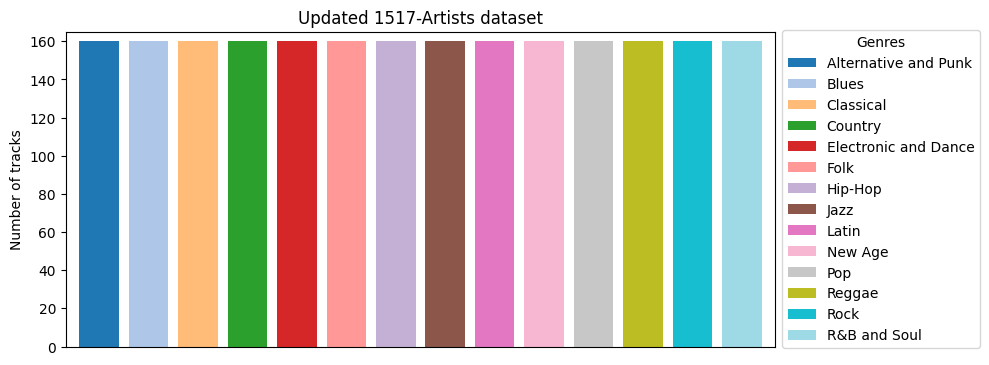

In [30]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.patches import Patch

# Example: replace with your actual data
# genres_sorted = {"Country": 185, "Folk": 182, ...}
names = [name.replace("_", " ") for name in genres_sorted.keys()]
values = list(genres_sorted.values())
num_genres = len(names)

# Generate colors
cmap = cm.get_cmap('tab20', num_genres)
colors = [cmap(i) for i in range(num_genres)]

# Plot
plt.figure(figsize=(10, 3.8))
x_pos = np.arange(num_genres)
bars = plt.bar(x_pos, values, color=colors)

# Hide x-axis labels
plt.xticks([])  # removes genre names below bars

# Set limits and labels
plt.ylim(0, max(values) + 5)
plt.ylabel("Number of tracks")
plt.title("Updated 1517-Artists dataset")
plt.margins(x=0.02)

# Add legend on the side
legend_elements = [Patch(facecolor=colors[i], label=names[i]) for i in range(num_genres)]
plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="Genres")

plt.tight_layout()
plt.savefig("merge_genre_distributions.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [29]:
values

[160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160]